# Choosing and inspecting resolutions

A finite encoding lets us study a module through its spaces and maps. A projective
resolution goes further: it supplies generators, relations, and relations among
relations. An injective resolution answers the dual question with cogenerators.
This guide explores their stored tables, selected maps and support diagrams.

You should already know how to read a finite poset and a matrix. We use a directly
supplied module, so no point cloud or filtration is needed. The same visual calls
accept the result of `resolve(enc)` for a filtration-derived encoding. All algebra
here belongs to the represented **finite-poset category**; see
[the category discussion](../math_categories.md) before interpreting ambient Ext
or multigraded invariants.

We will construct a tiny module, predict its resolution, inspect a relation and a
syzygy, and compare a truncated prefix with the complete answer. Install the
checkout's documentation environment for CairoMakie; the core tables can also be
inspected without loading a renderer.


In [1]:
import TamerOp as OP
import CairoMakie
using SparseArrays
const OA = OP.Advanced
const FF = OP.FiniteFringe
const MD = OP.Modules
field = OP.CoreModules.QQField()
K = OP.CoreModules.coeff_type(field);


Rational{BigInt}

## A module on a diamond

The order is $1<2<4$ and $1<3<4$, with 2 and 3 incomparable. Put a line at
vertex 1 and zero spaces elsewhere. All nonidentity maps are zero. This finite
module already has a finite encoding: the classifier is the identity.


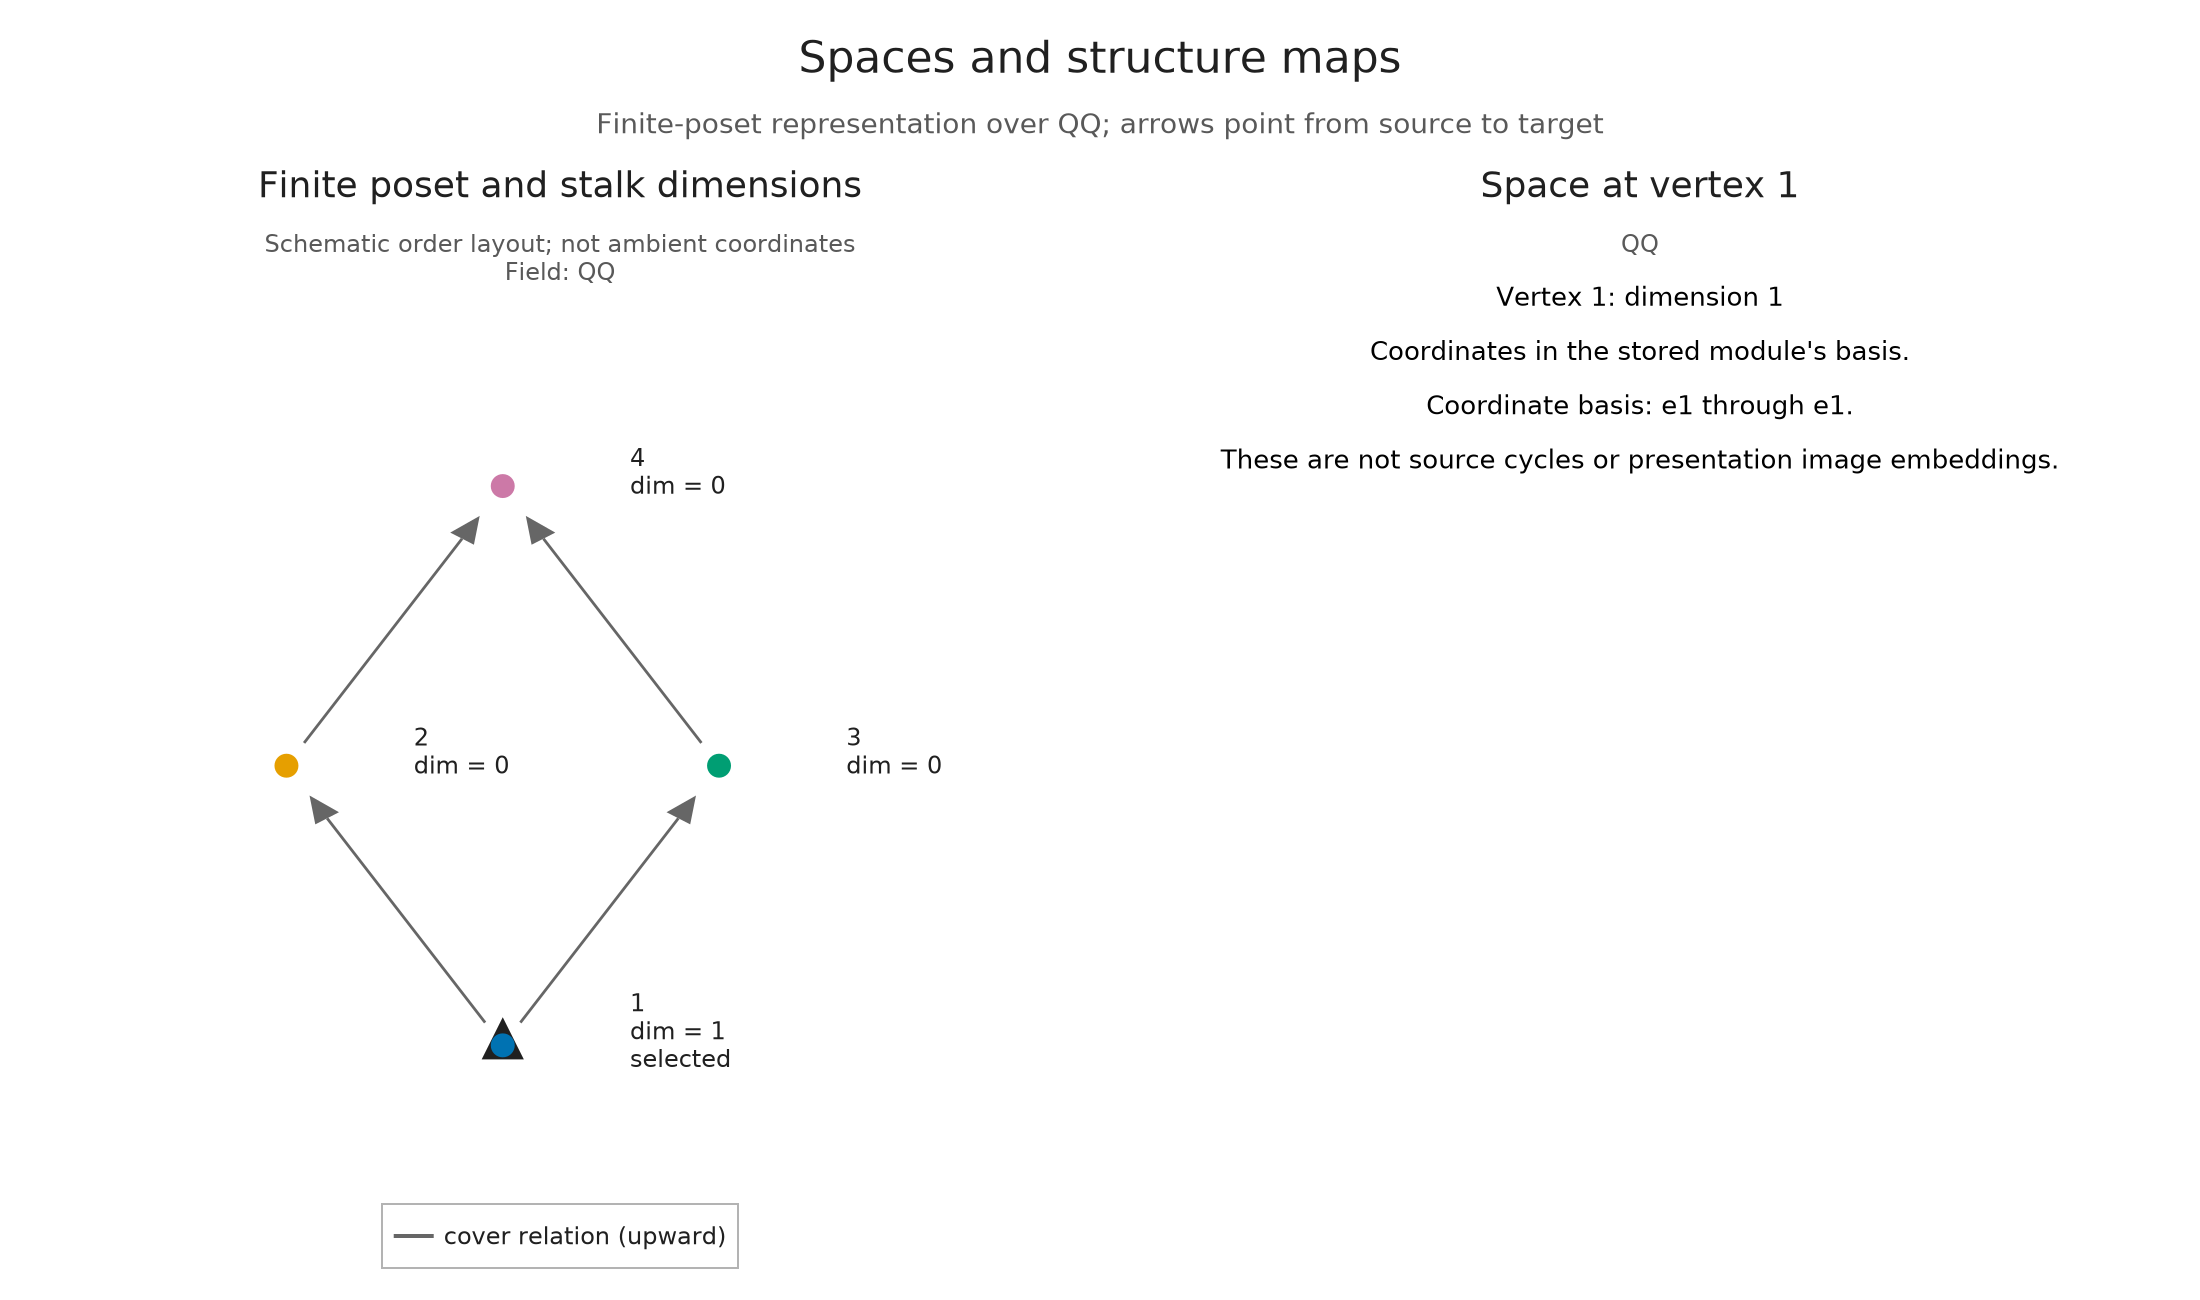

In [2]:
P = FF.FinitePoset(Bool[1 1 1 1; 0 1 0 1; 0 0 1 1; 0 0 0 1])
dims = [1, 0, 0, 0]
M = MD.PModule{K}(P, dims,
    Dict((u,v) => zeros(K, dims[v], dims[u]) for (u,v) in FF.cover_edges(P)); field)
classifier = OP.Encoding.EncodingMap(P, P, [1,2,3,4])
enc = OP.Results.EncodingResult(P, M, classifier)
@assert MD.check_module(M).valid
OP.visualize(M; kind=:module_inspector, vertex=1)


The first projective term is the principal upset at 1, which has a line at every
vertex. Mapping it onto our module leaves a kernel supported at 2, 3 and 4.
That kernel needs generators at 2 and 3. Their images agree at 4, producing one
relation between those generators. Thus the minimal multiplicities are:

| Degree | Vertex 1 | Vertex 2 | Vertex 3 | Vertex 4 |
|---|---:|---:|---:|---:|
| 0 | 1 | 0 | 0 | 0 |
| 1 | 0 | 1 | 1 | 0 |
| 2 | 0 | 0 | 0 | 1 |

The last differential has two nonzero entries with opposite signs over the
rationals. Its composite with the preceding differential vanishes.


In [3]:
resolution = OP.resolve(enc; opts=OA.ResolutionOptions(maxlen=2))
table = OA.visual_spec(resolution)
@assert OA.visual_metadata(table).counts == [1 0 0 0; 0 1 1 0; 0 0 0 1]
OA.visual_metadata(table).verification


(minimality = :not_checked, completion = :not_checked, checks = NamedTuple[])

The default table only counts stored summands. It does not silently certify
minimality or completion. `verify=true` checks the augmented equations,
exactness, minimality of the individual covers, and the terminal kernel.
Here those checks justify calling the counts Betti numbers of this finite module.


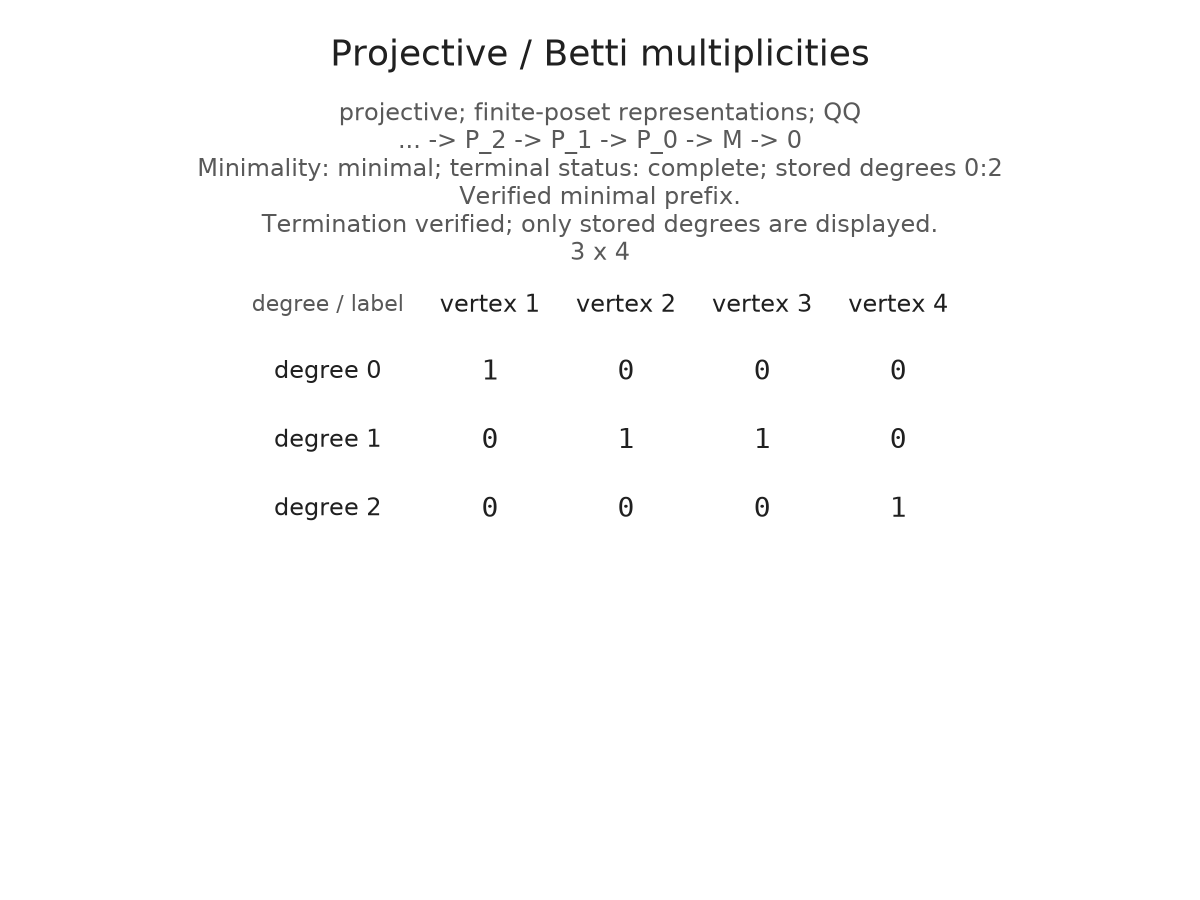

In [4]:
verified = OA.visual_spec(resolution; verify=true)
@assert OA.visual_metadata(verified).verification.minimality == :minimal
@assert OA.visual_metadata(verified).verification.completion == :complete
OP.visualize(verified)


## Follow a selected relation into its map

Select the first degree-one summand. Its support is a principal upset. The
coefficient panel highlights the corresponding **source column** of $d_1$;
rows identify degree-zero targets. At vertex 4 both degree-one summands are
active, so the stalk map has two columns.

`support_sheets=true` separates the summands of the selected resolution term
into support panels. This is a schematic drawing, not a decomposition of the
original module and not an additional filtration parameter.


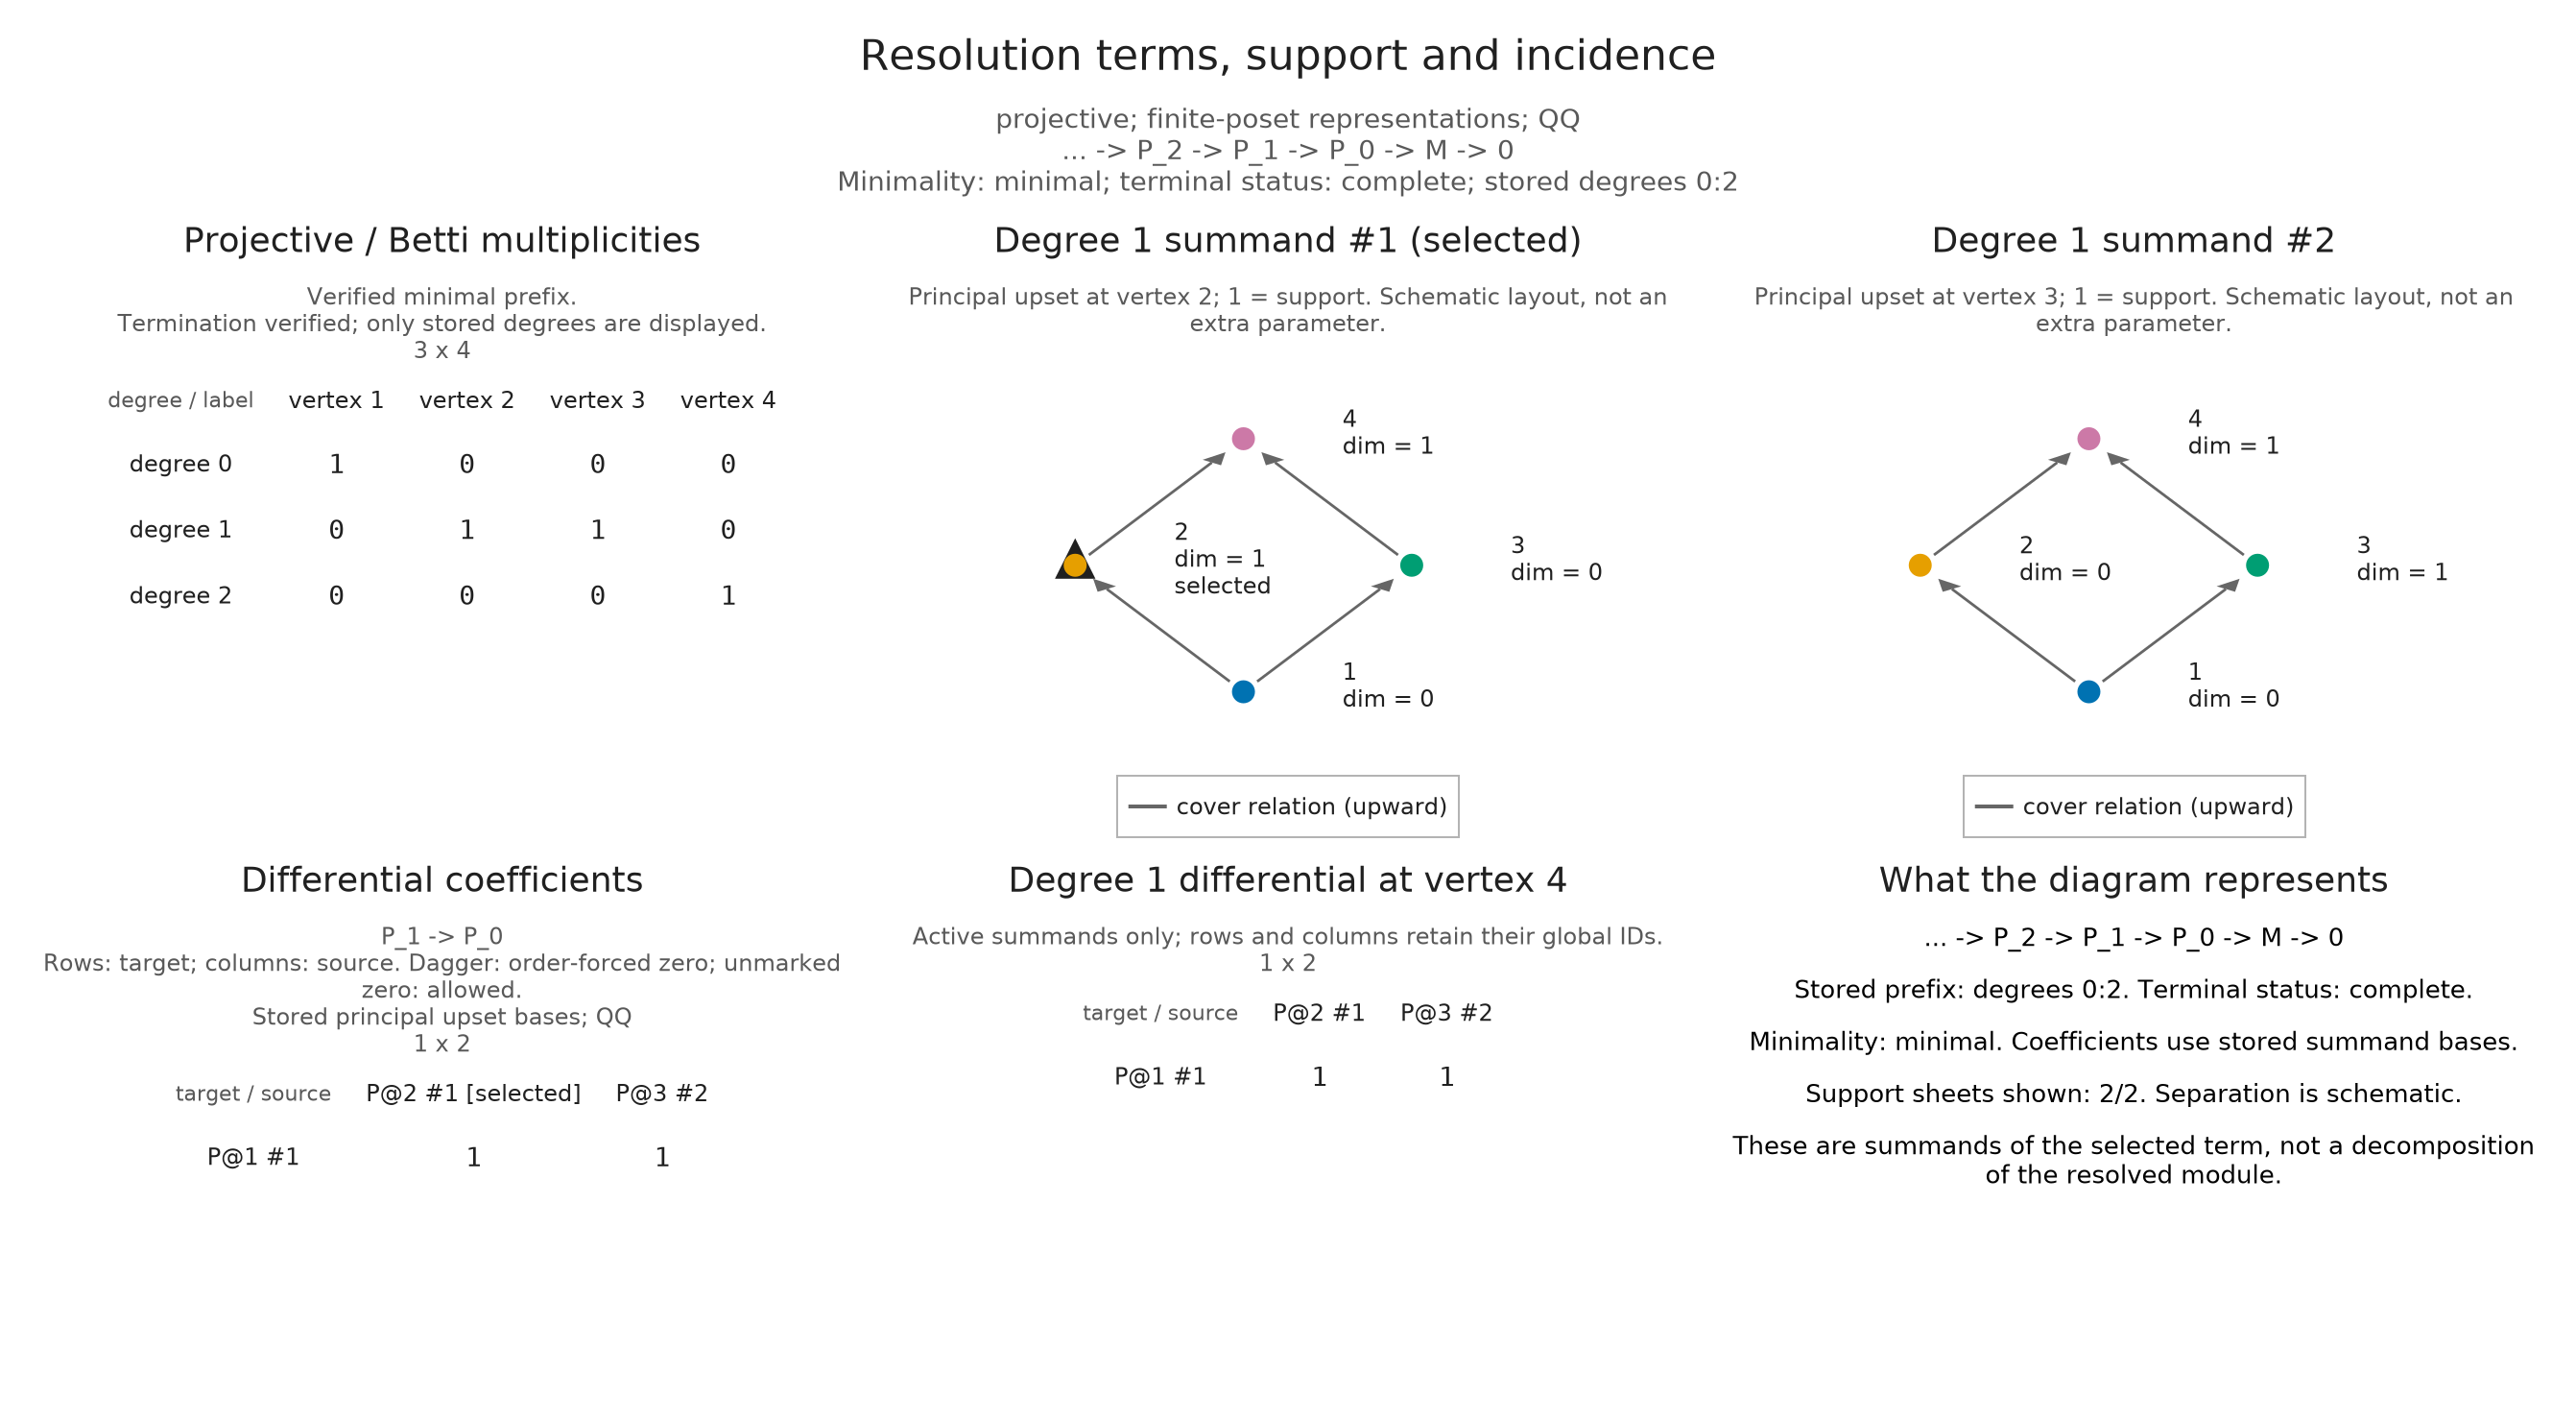

In [5]:
OP.visualize(resolution; kind=:resolution, degree=1, summand=1,
    vertex=4, support_sheets=true, verify=true)


Now select the degree-two syzygy. The matrix is displayed in its actual stored
basis, whose normalization need not agree with a hand calculation. The two
nonzero entries and the vanishing composite are the mathematical facts to check.


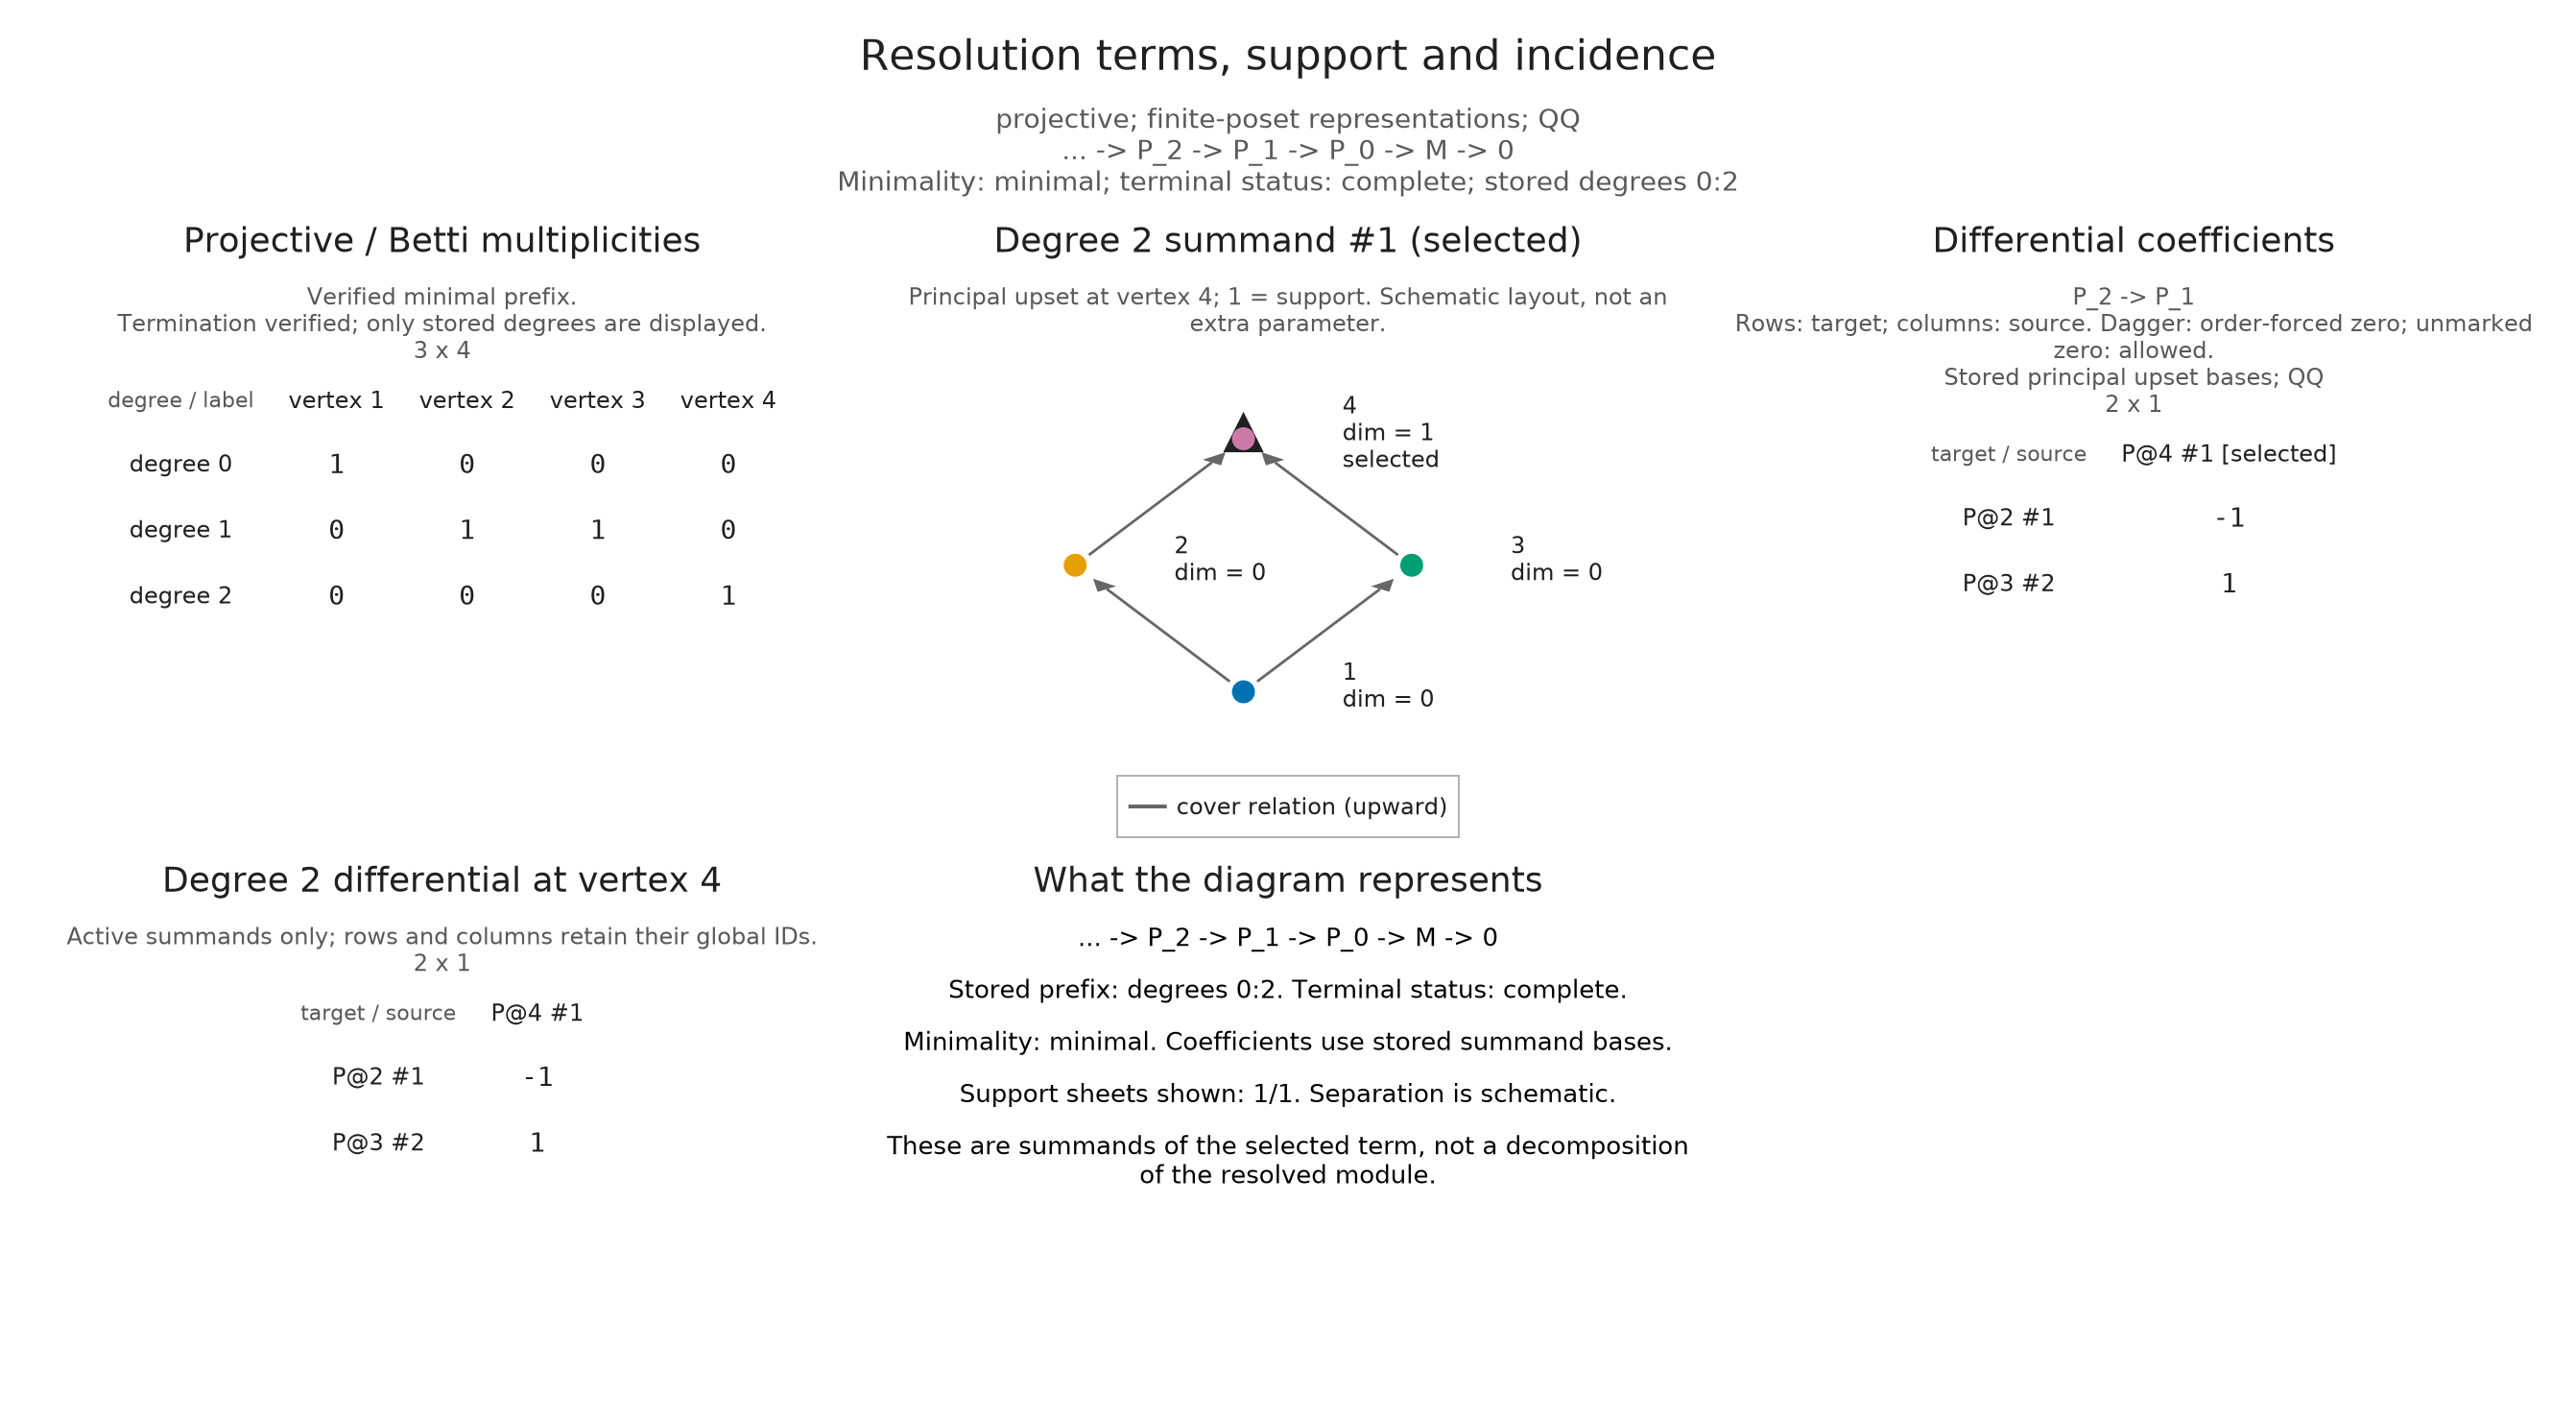

In [6]:
syzygy = OA.visual_spec(resolution; kind=:resolution, degree=2,
    summand=1, vertex=4, verify=true)
D2 = OA.visual_metadata(syzygy).coefficient_matrix
@assert size(D2) == (2,1) && all(!iszero, D2)
D1 = OA.visual_metadata(OA.visual_spec(resolution; kind=:resolution, degree=1)).coefficient_matrix
@assert all(iszero, D1*D2)
OP.visualize(syzygy)


## A cutoff is not a vanishing theorem

With `maxlen=0`, only the cover is stored. It is still minimal, but its kernel is
nonzero. Missing higher degrees therefore remain unknown. The table contains
one row, and the verification identifies a truncated prefix.


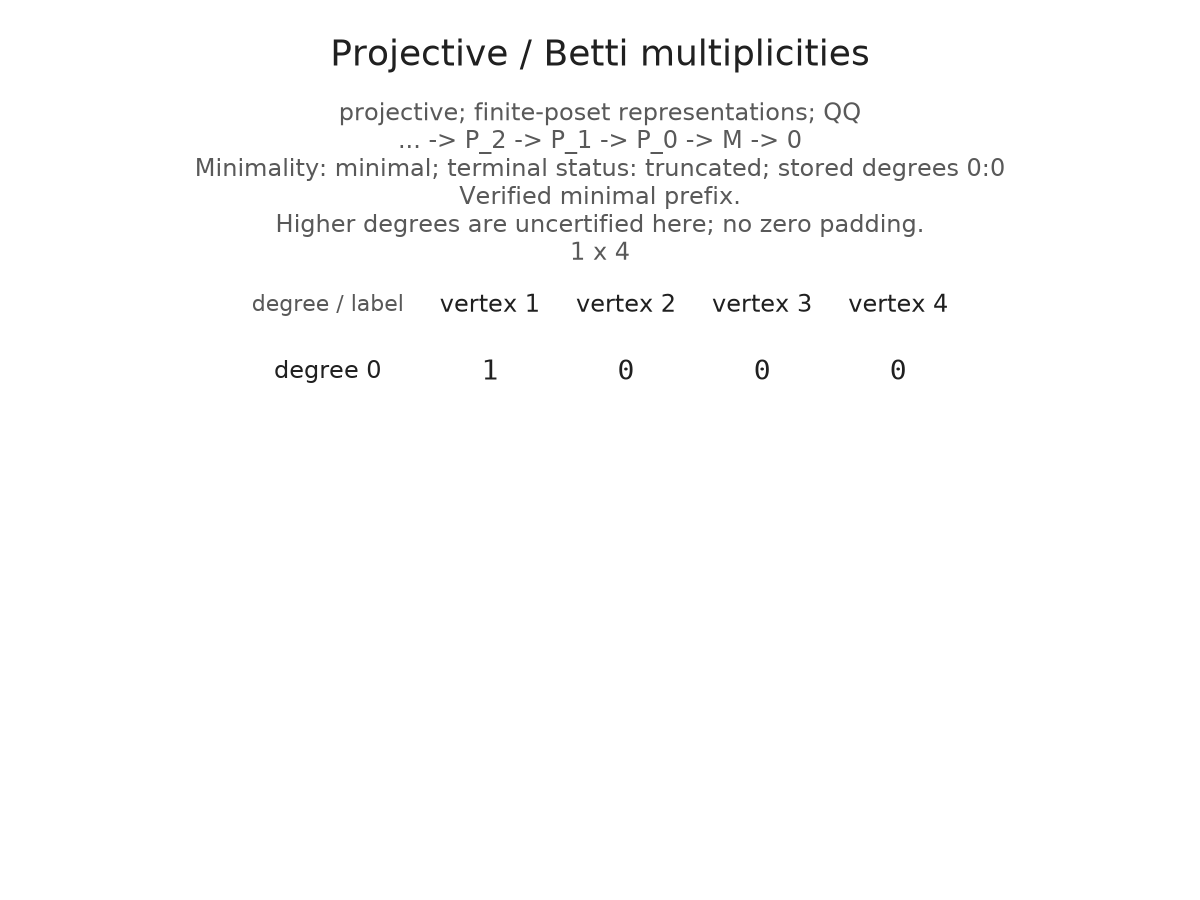

In [7]:
prefix = OP.resolve(enc; opts=OA.ResolutionOptions(maxlen=0))
prefix_view = OA.visual_spec(prefix; verify=true)
@assert size(OA.visual_metadata(prefix_view).counts) == (1,4)
@assert OA.visual_metadata(prefix_view).verification.completion == :truncated
OP.visualize(prefix_view)


## Grades are extra mathematical data

A degree-by-vertex table works on any finite poset. A grade-plane picture needs
actual supplied coordinates whose product order agrees with that poset.
Here the four corners of a square give such an order embedding. Each dot is
labelled by its finite vertex and multiplicity; coincident summands are counted,
not silently overplotted.

These are **finite-poset** multiplicities plotted at supplied coordinates.
Providing coordinates does not prove that this is a minimal multigraded free
resolution of an ambient persistence module. That separate category and
extension question matters in [RIVET's bigraded Betti convention](https://rivet.readthedocs.io/en/latest/preliminaries.html#invariants-of-a-bipersistence-module).


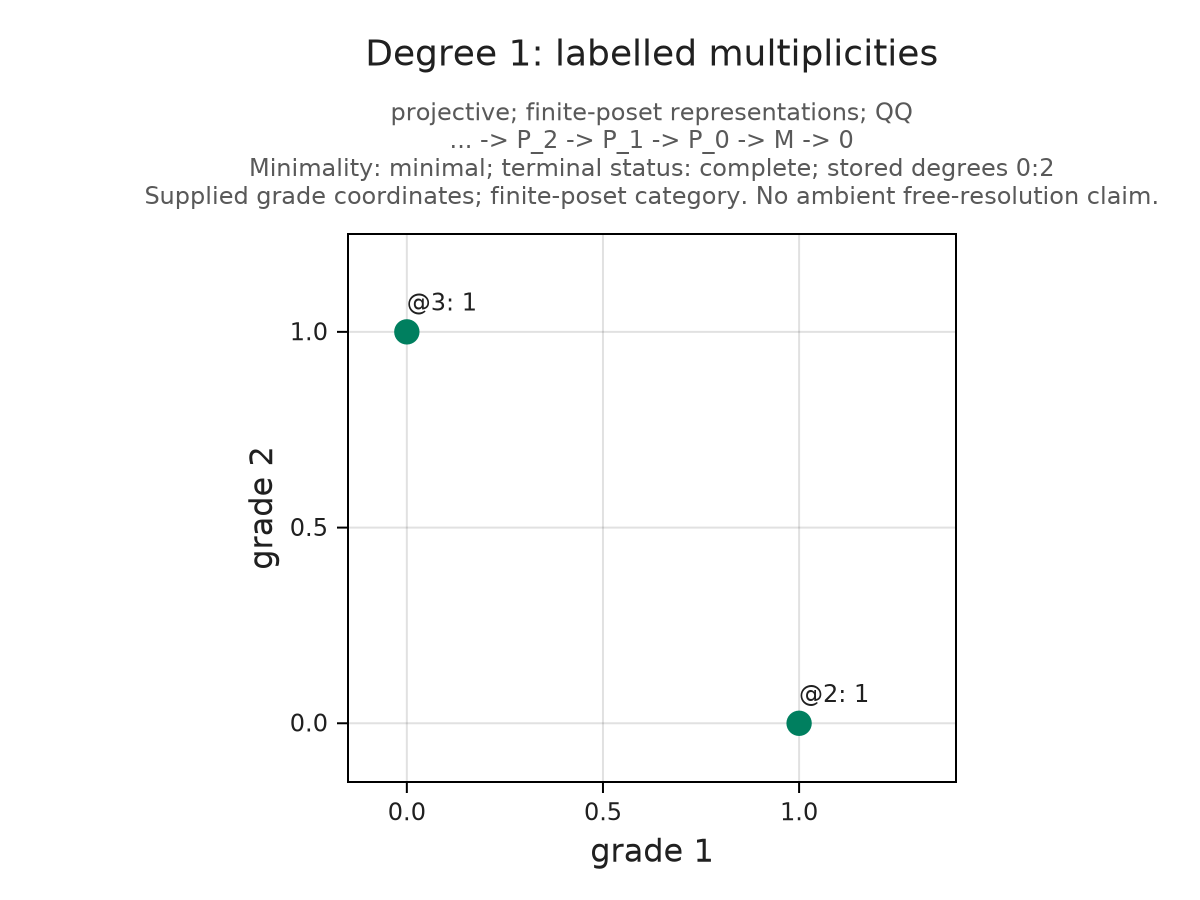

In [8]:
grades = [(0,0), (1,0), (0,1), (1,1)]
OP.visualize(resolution; kind=:betti_degrees, degree=1, grades, verify=true)


Try reversing the grade list. Does it still represent the same order? Predict
the answer before running the request validator below. A Hasse layout is not a
substitute for grades: its drawing positions express readability, not a
coordinatewise parameter order.


In [9]:
invalid = OA.check_visual_request(resolution; kind=:betti_degrees, grades=reverse(grades))
@assert !invalid.valid
invalid.issues


1-element Vector{String}:
 "ArgumentError: grades must be a" ⋯ 57 bytes ⋯ "ut coordinates are not grades."

## The injective direction

For a dual example, put the line at vertex 4. The injective resolution starts
with the principal downset at 4, followed by downsets at 2 and 3, then at 1.
The arrows now run $M\to I^0\to I^1\to I^2$. A selected positive degree marks
its row in the incoming differential, rather than a source column.


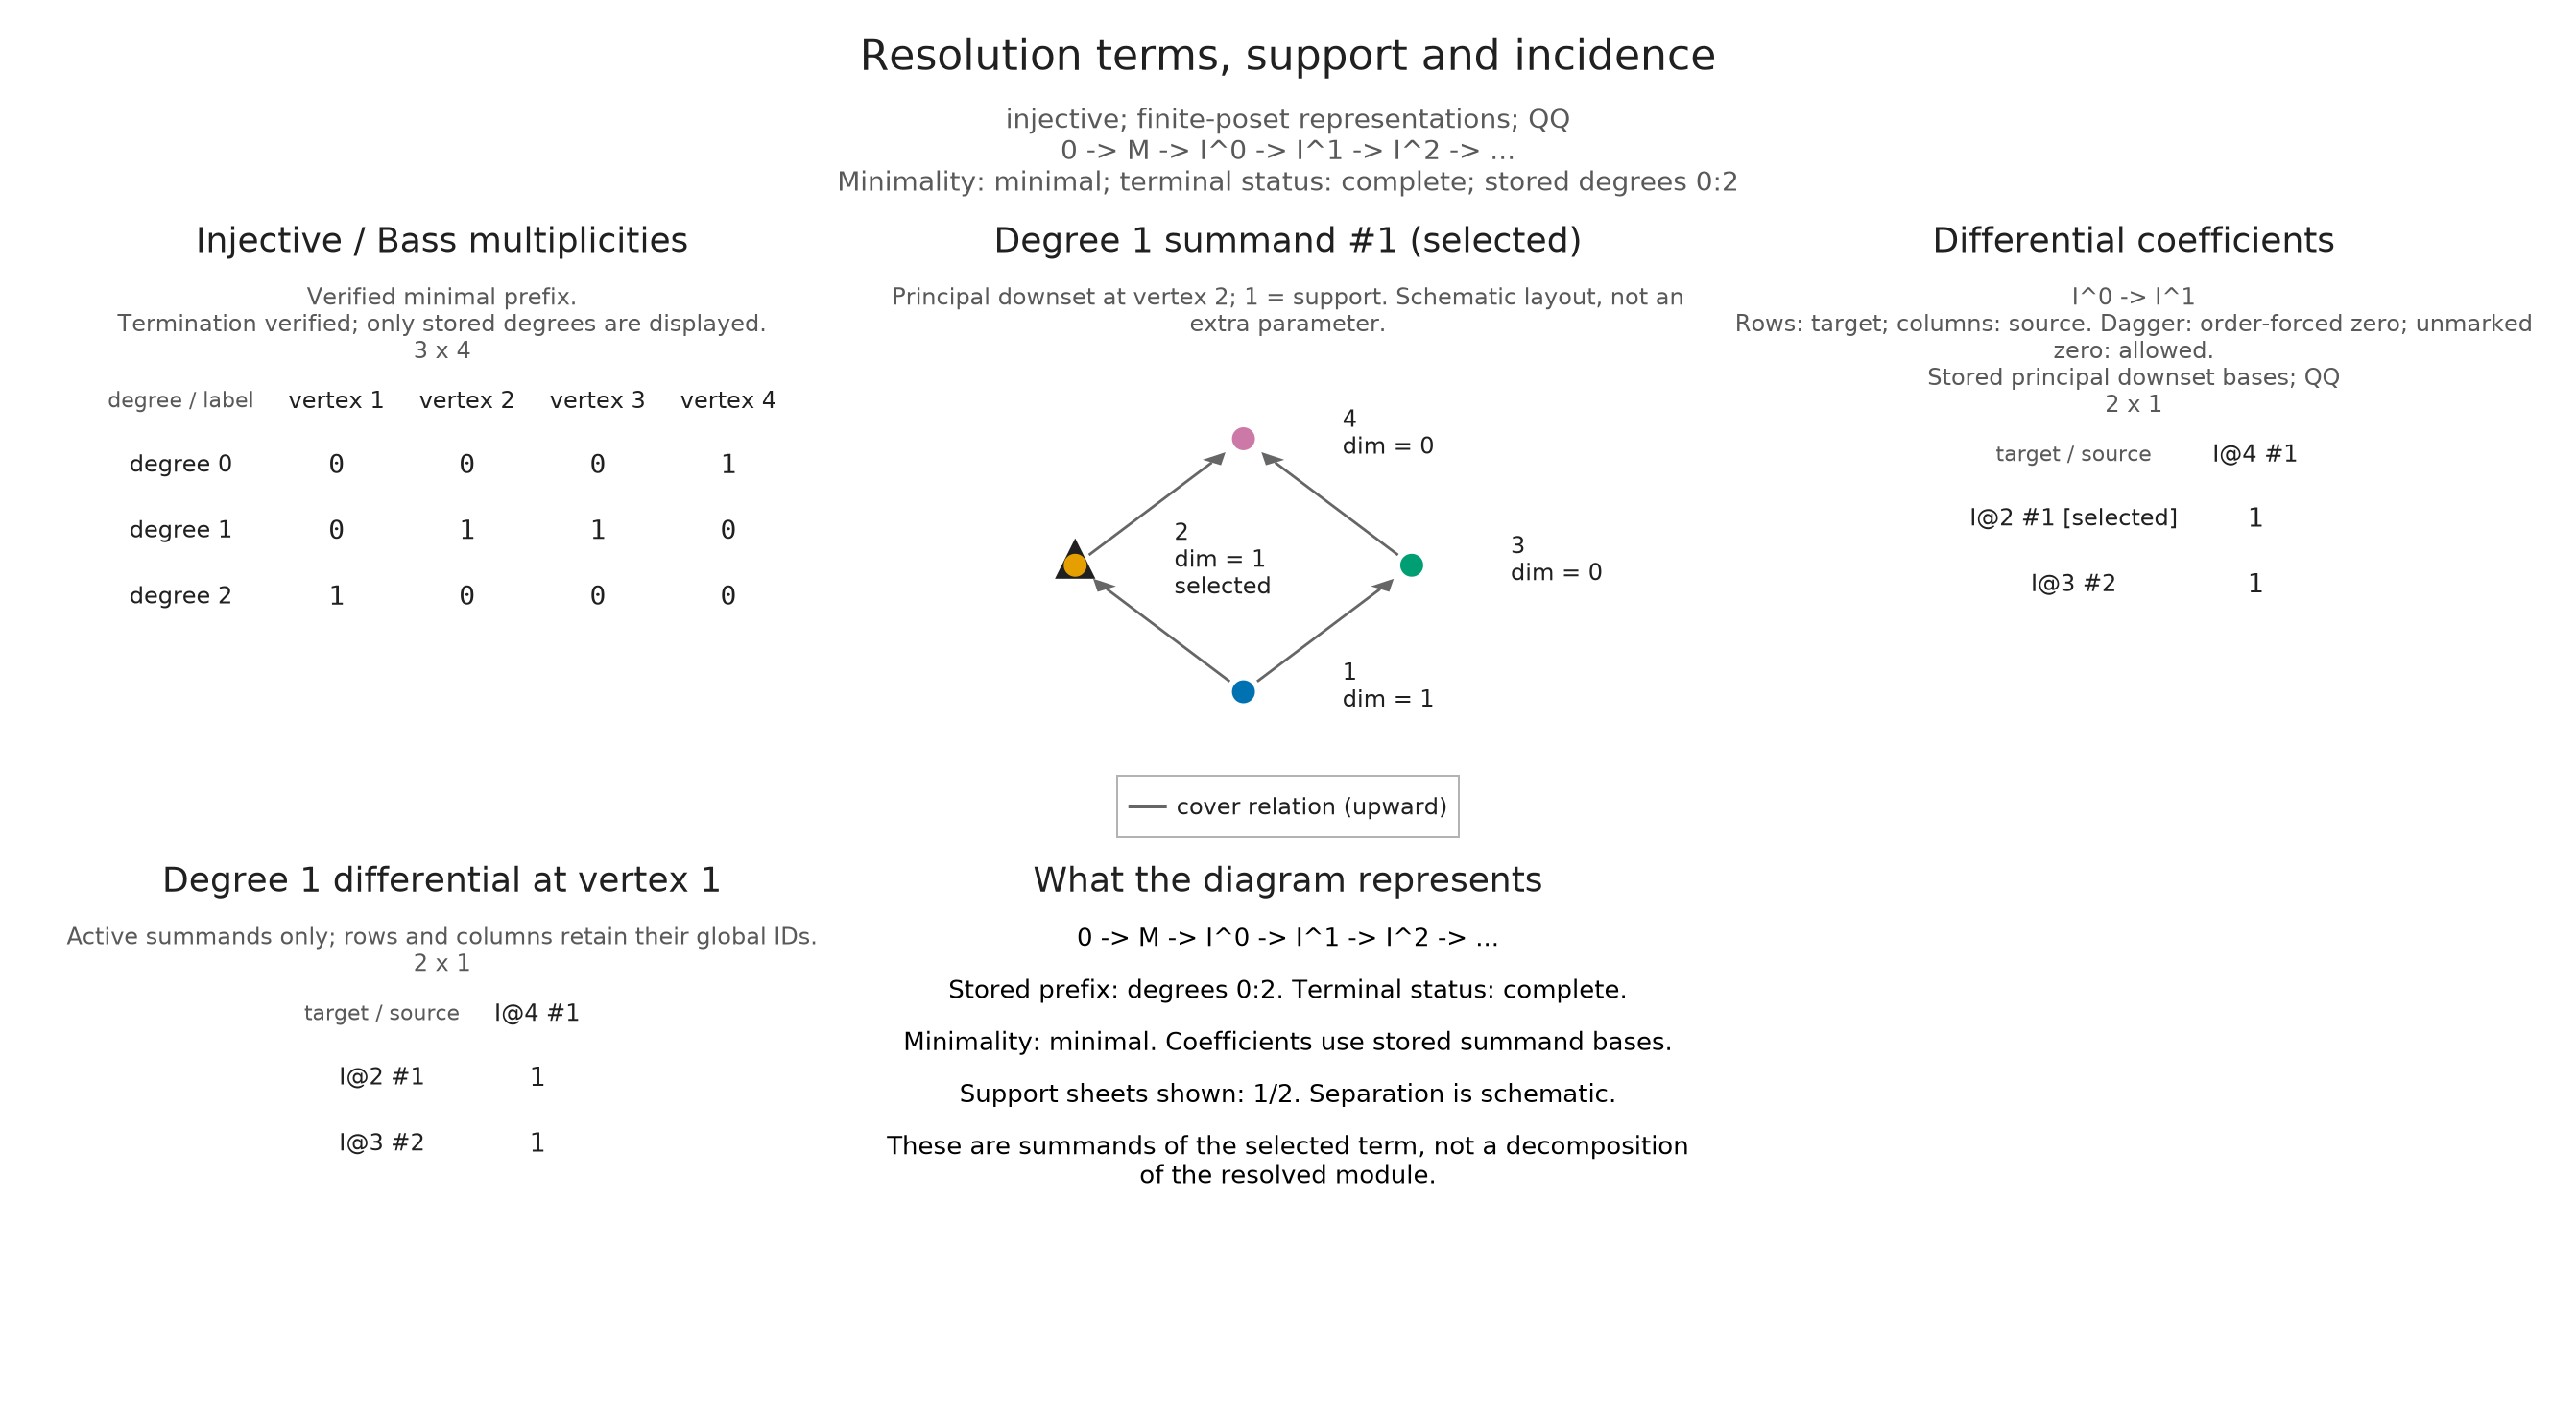

In [10]:
dual_dims = [0,0,0,1]
N = MD.PModule{K}(P, dual_dims,
    Dict((u,v) => zeros(K, dual_dims[v], dual_dims[u]) for (u,v) in FF.cover_edges(P)); field)
dual_enc = OP.Results.EncodingResult(P, N, classifier)
injective = OP.resolve(dual_enc; kind=:injective, opts=OA.ResolutionOptions(maxlen=2))
bass = OA.visual_spec(injective; verify=true)
@assert OA.visual_metadata(bass).counts == [0 0 0 1; 0 1 1 0; 1 0 0 0]
OP.visualize(injective; kind=:resolution, degree=1, summand=1, vertex=1, verify=true)


## Inspect a presentation before minimizing it

A projective presentation gives a **cokernel**. This differs from a fringe
presentation, which gives the image of a map from upsets to downsets.
The following two generators have labels 1 and 2 on a chain. Matrix columns
label relations, rows label generators. The lower-left entry is forced to zero
by order; the lower-right entry happens to be zero. The figure marks only the
forced entry with a dagger.

`UpsetPresentation` stores the transpose of that source-column matrix. The
viewer handles the convention and labels the displayed rows and columns.


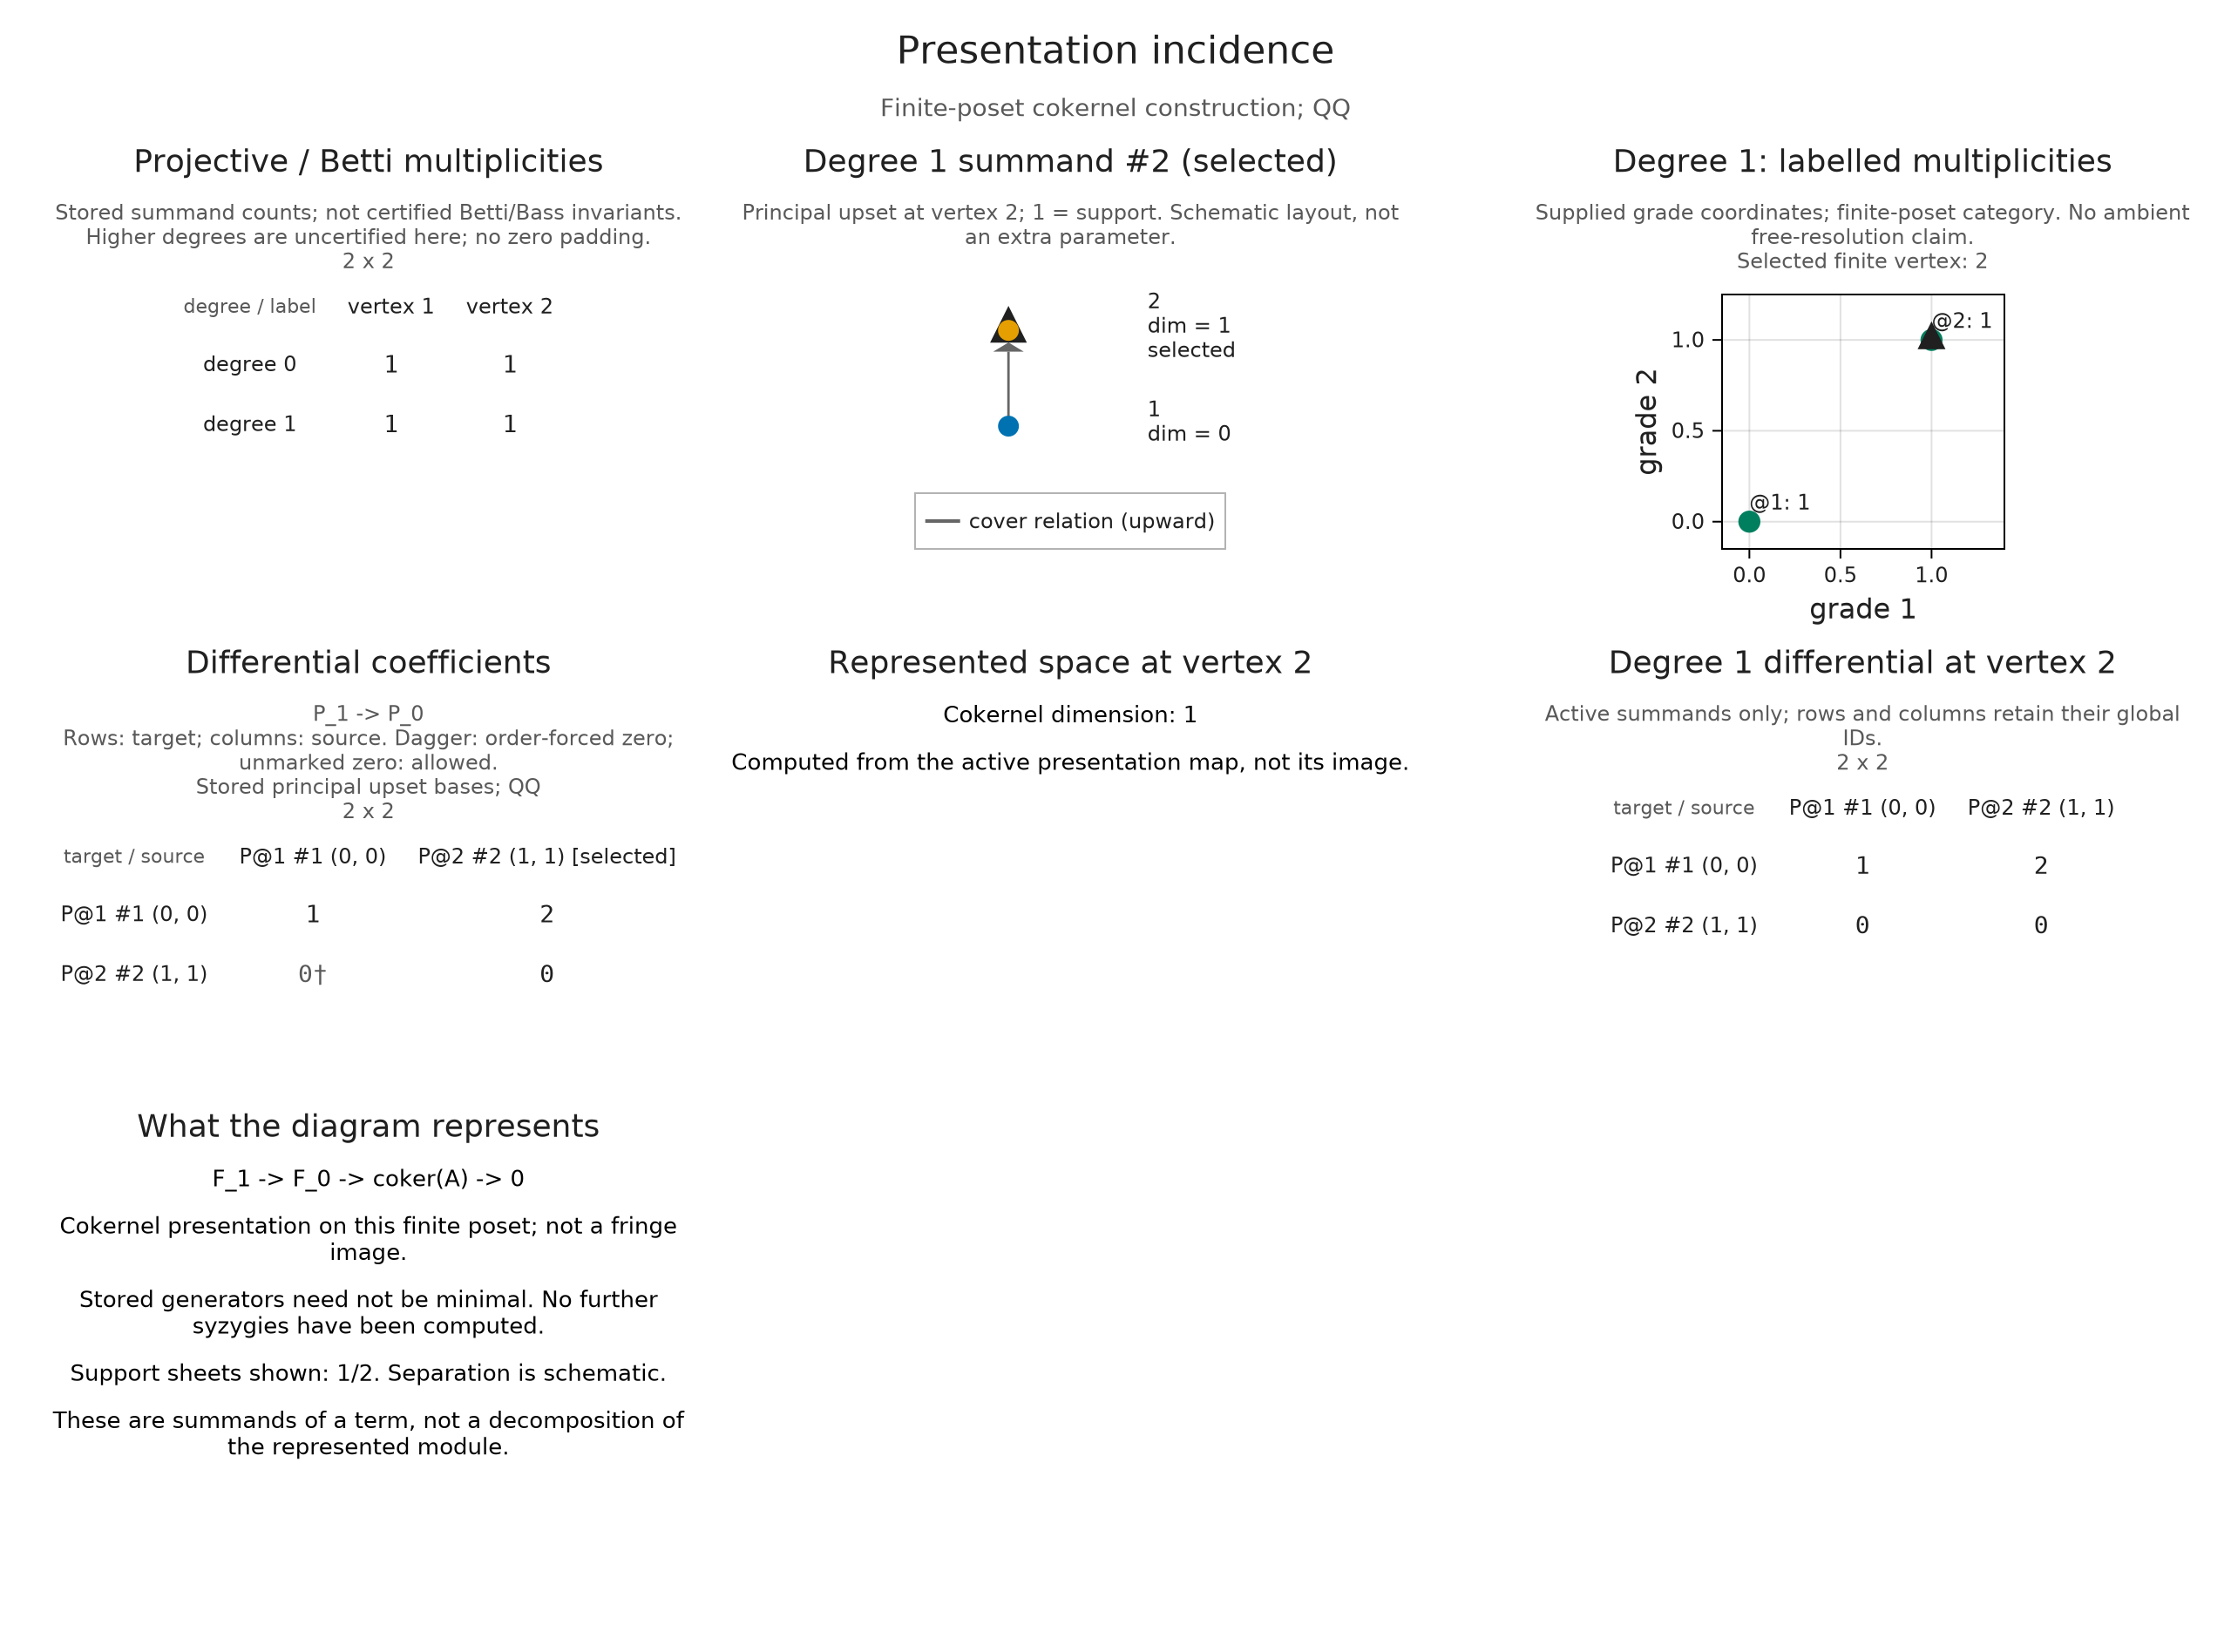

In [11]:
Q = FF.FinitePoset(Bool[1 1; 0 1])
U = [FF.principal_upset(Q,1), FF.principal_upset(Q,2)]
A = K[1 2; 0 0]
presentation = OP.IndicatorTypes.UpsetPresentation{K}(Q, U, U, copy(transpose(A)), nothing)
OP.visualize(presentation; degree=1, summand=2, vertex=2, grades=[(0,0),(1,1)])


A supplied graded basis change can make the same presentation look different.
Here $S$ changes the relation basis and $T$ changes the generator basis. The
viewer checks invertibility and order compatibility, then verifies
$AS=TB$, where $B=T^{-1}AS$. It does not search for a decomposition or change
any stored object. For a resolution, this operation certifies only the selected
differential; transforming a whole resolution would also transform its
adjacent maps and augmentation.


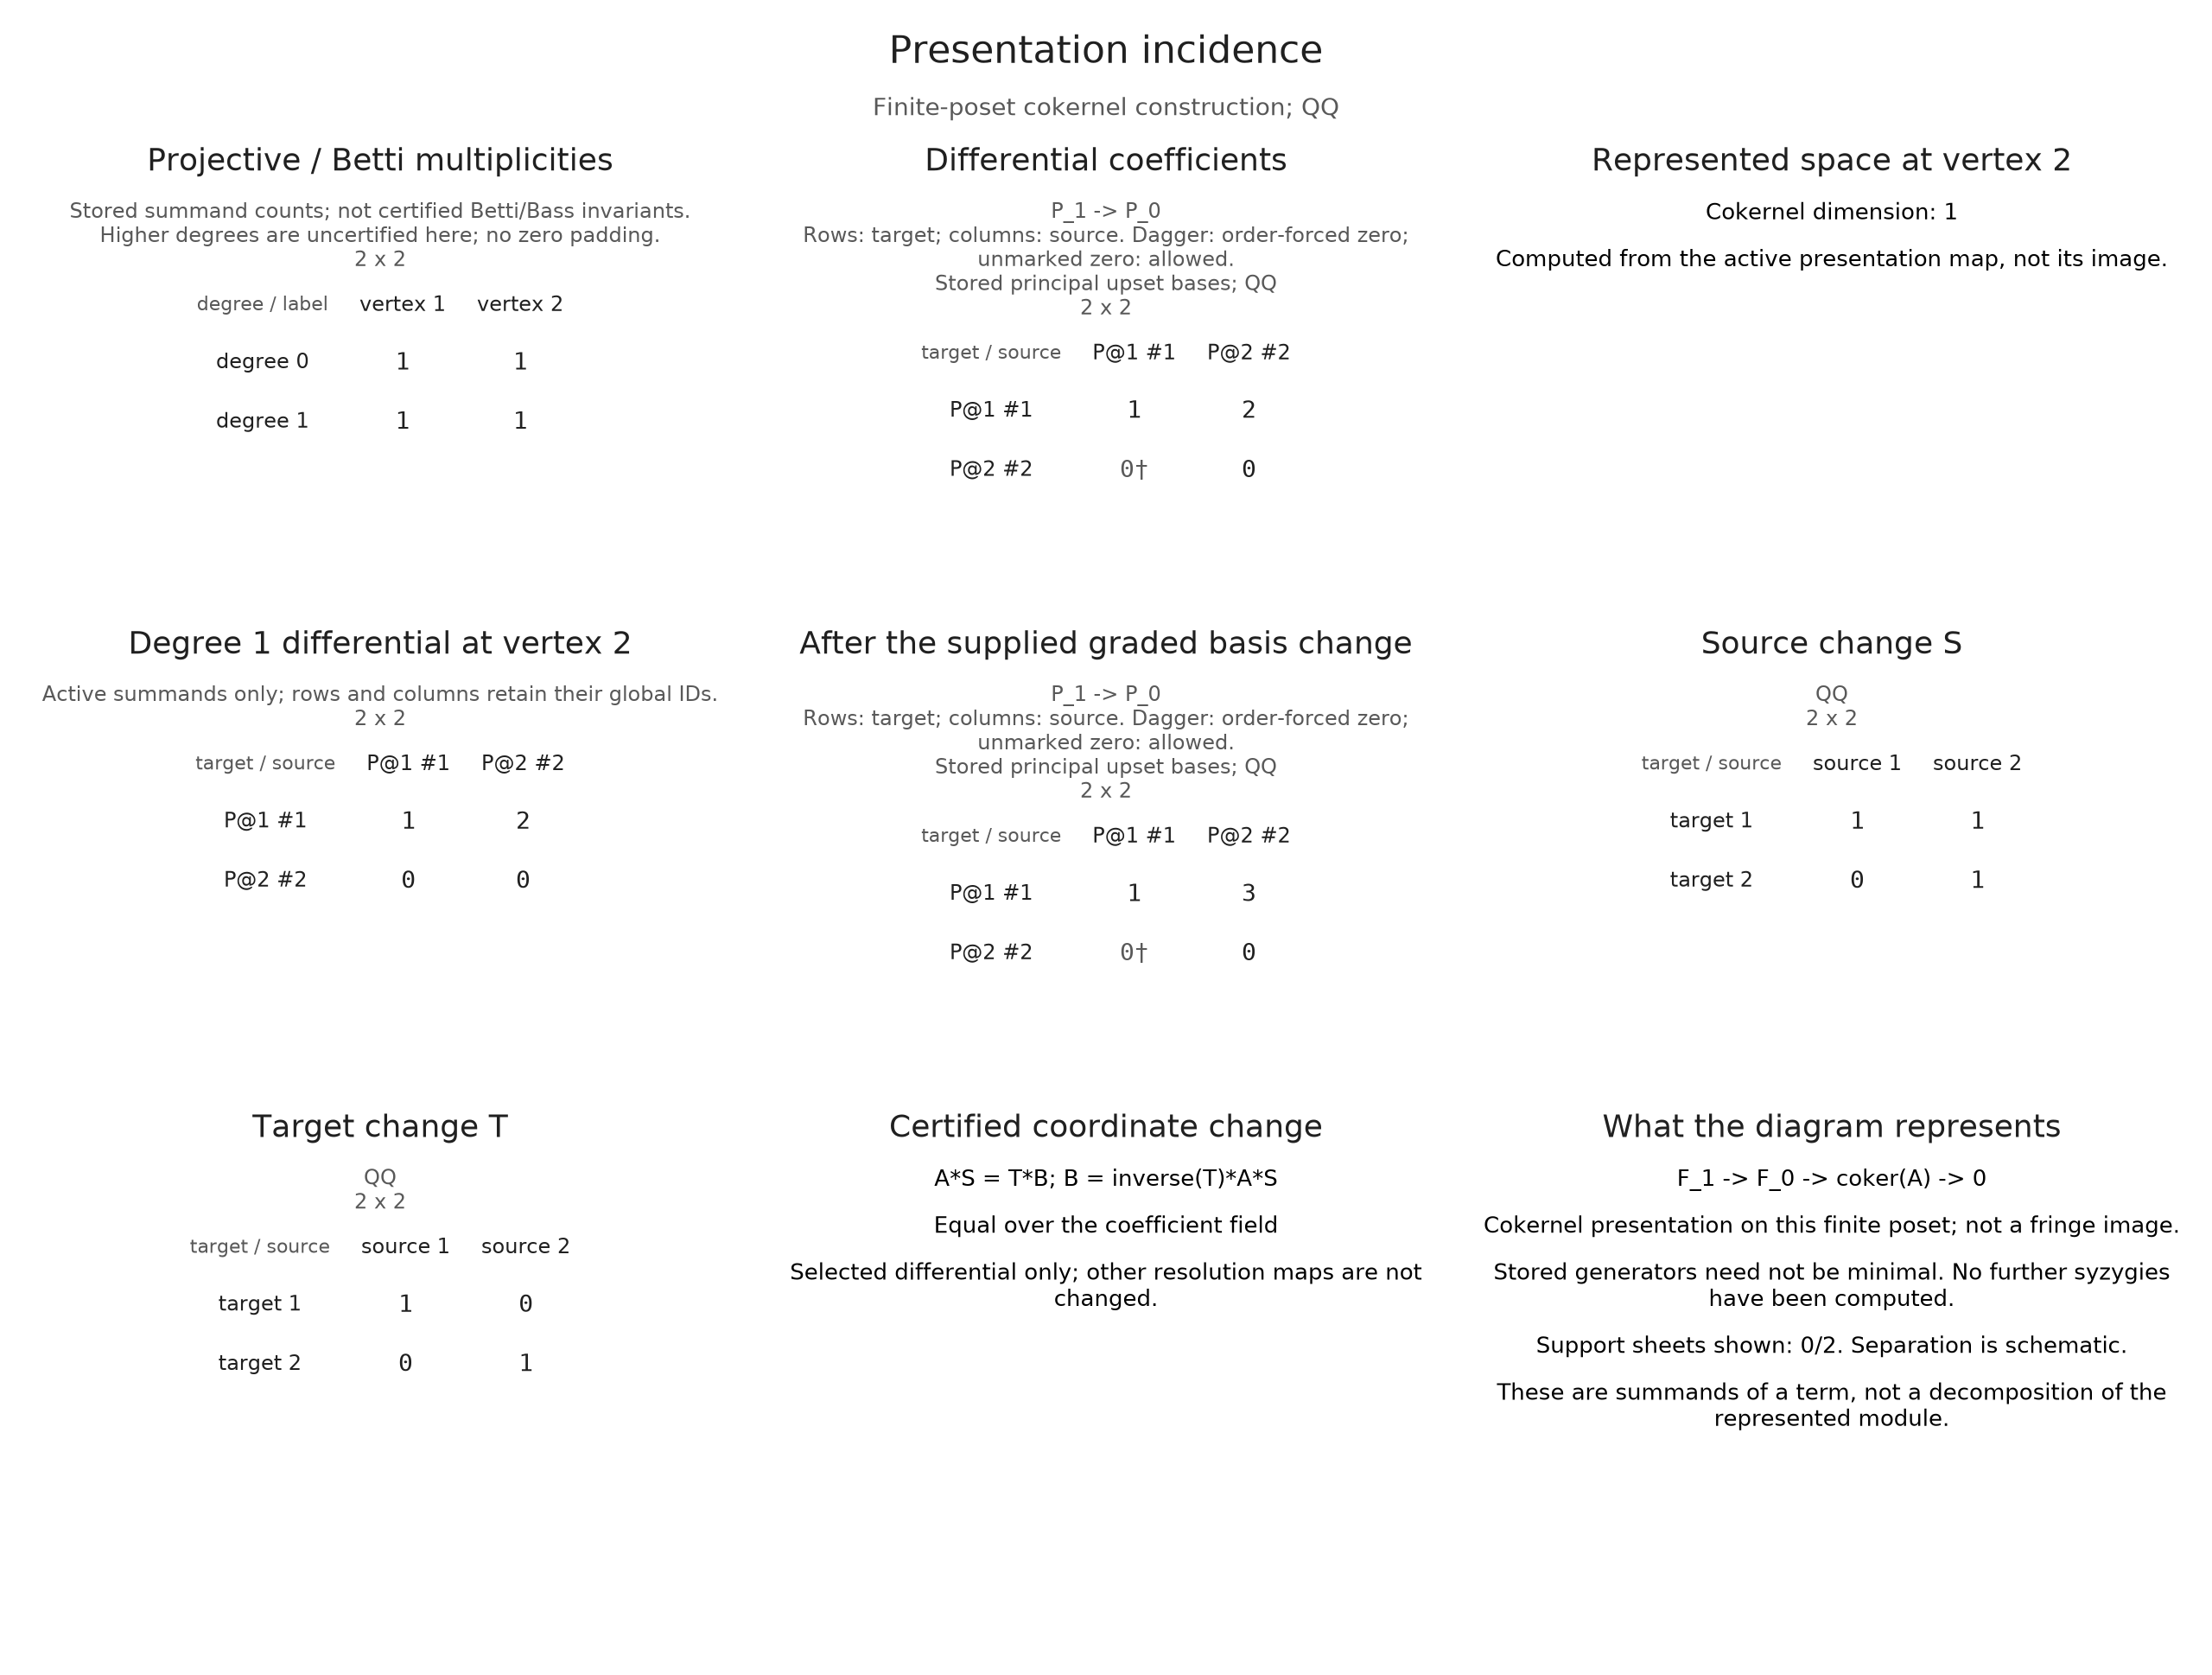

In [12]:
S = K[1 1; 0 1]
T = K[1 0; 0 1]
changed = OA.visual_spec(presentation; degree=1, vertex=2,
    basis_change=(; source=S, target=T))
@assert OA.visual_metadata(changed).basis_change.matrix == K[1 3; 0 0]
@assert OA.visual_metadata(changed).represented_dimension == 1
OP.visualize(changed)


The same resolution views accept `IndicatorResolutions.upset_resolution(M)`
and `downset_resolution(M)`, using their recorded principal summands. They do
not infer birth labels for arbitrary nonprincipal supports. Exact fields retain
literal coefficients; `RealField` verification uses its declared tolerances
and numerical rank decisions.

`matrix_limit` limits displayed rows and columns, while specification metadata
retains the full selected matrix and multiplicity table. Support panels use its
row limit and always retain an explicitly selected summand. A figure reports
its displayed/total scope. Selections are Julia arguments, so both CairoMakie
and WGLMakie render the same static mathematical specification.

For exact keyword and verification contracts, consult the
[visualization reference](../src/reference/visualization.md#resolutions-and-presentation-incidence).
For reusing a computed resolution, see [computation reuse](../lazy_inspection.md).
Saving uses the shared [visualization export workflow](../visualization.md#rendering-and-saving).
